# 03. Comparación estadística de cinco cortes temporales
El análisis describe los cortes 7, 14, 28, 42 y 56. Se mantienen las distinciones
entre inscripción y persona, entre asociación y predicción y entre variación temporal
y cambio de población. No se buscan valores p ni una ventana ganadora. Los intervalos
puntuales de efectos se obtienen con remuestreo de personas dentro de cada corte;
su solapamiento no constituye una prueba de diferencia entre cortes.


In [1]:
import os, sys, json
from pathlib import Path
candidate = Path(os.environ.get('OULAD_ROOT', Path.cwd())).resolve()
ROOT = next(p for p in [candidate, *candidate.parents] if (p / 'data/raw/studentInfo.csv').exists())
sys.path.insert(0, str(ROOT / 'src'))
from oulad_revision import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 40)
print(environment())


{'python': '3.11.9', 'packages': {'pandas': '2.3.3', 'numpy': '2.4.4', 'scipy': '1.17.1', 'matplotlib': '3.10.9', 'scikit-learn': '1.8.0', 'pyarrow': '24.0.0'}}


## 1. Identidad de productos y población
Se verifica el SHA-256 del dataset apilado y su unicidad por inscripción y corte.
Los tamaños por corte se reportan por separado; sumar las filas apiladas no produce
un número de personas. El evento es el retiro posterior a cada corte y hasta el final
de la presentación. El seguimiento restante disminuye al avanzar el corte.


In [2]:
from ventanas_oulad import PREDICTORS
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import MinCovDet
hashes=json.loads((OUT/'productos_02.json').read_text(encoding='utf-8'))
assert sha256(PROCESSED/'dataset_multiventana.parquet')==hashes['dataset_multiventana.parquet']
stack=pd.read_parquet(PROCESSED/'dataset_multiventana.parquet')
CUTS=sorted(stack.corte.unique().tolist());datasets={int(t):d.copy() for t,d in stack.groupby('corte')}
assert not stack.duplicated(KEY+['corte']).any()
for cut,d in datasets.items():
    assert d.date_registration.le(cut).all()
    assert (d.date_unregistration.isna()|d.date_unregistration.gt(cut)).all()
NUM=['total_clics','proporcion_dias_activos','promedio_clics_por_dia_activo',
     'coef_variacion_clics','cv_intensidad_activa','studied_credits','num_of_prev_attempts','dias_desde_ultima_interaccion','recencia_relativa',
     'clics_ultimos_7d','log_ratio_7d','log_ratio_14d',
     'n_evaluaciones_entregadas','proporcion_programadas_entregadas']
print(pd.read_csv(OUT/'tablas/02_comparacion_cortes.csv').to_string(index=False))


 corte  dias_observados  inscripciones  personas  retiros  prevalencia_pct  sin_actividad  sin_evaluacion_programada  con_entregas  matricula_posterior_inicio  horizonte_min  horizonte_max
     7                8          29076     26030     6632        22.809190           5316                      29076           772                         140            227            262
    14               15          28054     25220     5580        19.890212           2551                      26765          3226                         173            220            255
    28               29          27515     24826     5012        18.215519           1203                       4988         19849                         208            206            241
    42               43          27005     24491     4500        16.663581            918                       2426         22276                         210            192            227
    56               57          26506     24105     39

## 2. Distribuciones, oportunidades y atípicos
Se calculan descriptivos por corte con denominadores observados. Los totales crecen
con el tiempo de observación; las proporciones de actividad permiten una lectura
complementaria. La ausencia de una tendencia por historia insuficiente no se confunde
con cero ni con pérdida de registros. IQR o MAD iguales a cero dejan el diagnóstico
correspondiente como no aplicable. No se eliminan atípicos.


03_descriptivos
 corte                          variable     n  faltantes      media         q1    mediana         q3  ceros_pct  asimetria  curtosis_exceso
     7                       total_clics 29076          0  75.809430   5.000000  36.000000 100.000000  18.283120   5.516239        90.757909
     7           proporcion_dias_activos 29076          0   0.357632   0.125000   0.250000   0.625000  18.283120   0.569882        -0.693809
     7     promedio_clics_por_dia_activo 23760       5316  23.024408   9.250000  17.666667  30.000000   0.000000   4.232937        65.420826
     7              coef_variacion_clics 23760       5316   1.852082   1.298989   1.827333   2.525468   0.000000   0.044611        -1.134179
     7              cv_intensidad_activa 18704      10372   0.785365   0.552787   0.774619   1.010153   1.197605   0.170907        -0.011043
     7                   studied_credits 29076          0  77.278511  60.000000  60.000000  90.000000   0.000000   1.707580         5.6627

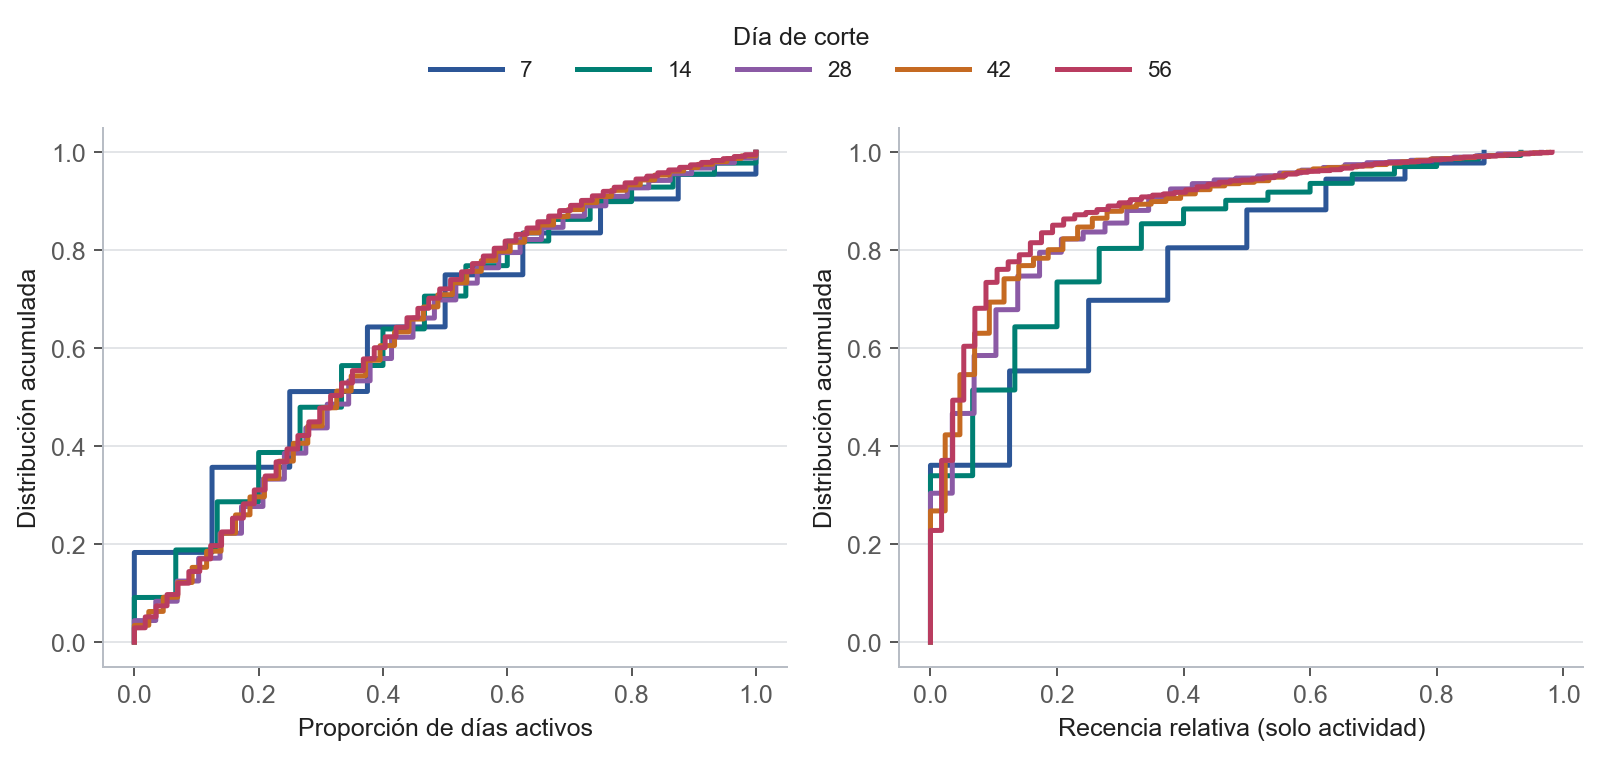

In [3]:
desc=[];outliers=[];missing=[]
for cut,d in datasets.items():
    for v in NUM:
        s=d[v].dropna()
        if s.empty:
            desc.append({'corte':cut,'variable':v,'n':0,'faltantes':len(d)});continue
        q1,median,q3=s.quantile([.25,.5,.75]);iqr=q3-q1;mad=stats.median_abs_deviation(s,scale='normal')
        desc.append({'corte':cut,'variable':v,'n':len(s),'faltantes':int(d[v].isna().sum()),
          'media':s.mean(),'q1':q1,'mediana':median,'q3':q3,'ceros_pct':100*s.eq(0).mean(),
          'asimetria':s.skew(),'curtosis_exceso':s.kurt()})
        outliers.append({'corte':cut,'variable':v,'n':len(s),'IQR':iqr,'MAD':mad,
          'tukey_1_5':int(((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum()) if iqr>0 else np.nan,
          'z_robusto':int((abs(s-median)/mad>3.5).sum()) if mad>0 else np.nan})
    masks={'sin_actividad':d.sin_actividad_acumulada.eq(1),'sin_entregas':d.sin_entregas_acumuladas.eq(1),
      'sin_programadas':d.sin_evaluacion_programada.eq(1),'imd_ausente':d.imd_band.isna(),
      'entrega_sin_puntaje':d.n_evaluaciones_entregadas.gt(0)&d.n_puntajes_observados.eq(0)}
    for name,mask in masks.items():
        for state in [False,True]:
            sub=d.loc[mask.eq(state)]
            missing.append({'corte':cut,'condicion':name,'presente':state,'n':len(sub),
              'retiros':int(sub.retiro_futuro.sum()),'tasa_pct':100*sub.retiro_futuro.mean()})
table('03_descriptivos',pd.DataFrame(desc));table('03_atipicos',pd.DataFrame(outliers))
table('03_condiciones',pd.DataFrame(missing))
from figuras_oulad import distribuciones_cortes
distribuciones_cortes(datasets)
figure('03_distribuciones_cortes')


## 3. Efectos e incertidumbre por corte
El efecto biserial compara P(X en retiro > X sin retiro) menos la probabilidad inversa,
con empates tratados mediante medio crédito en U. Se emplean 500 remuestras de
personas, semilla 20260908, conservando sus inscripciones. Cada estimación se
condiciona a sus casos observados y a las presentaciones incluidas. No se asume
independencia entre ventanas ni se comparan sus intervalos como si fueran pruebas
pareadas. Los mecanismos MAR/MNAR no se deducen de estas asociaciones.


03_estabilidad_bootstrap
 corte                          variable    B  validas  inferior  superior  cambio_max_frente_5000
     7                       total_clics  500      500 -0.195118 -0.162883                0.000806
     7                       total_clics 2000     2000 -0.194820 -0.163887                0.000197
     7                       total_clics 5000     5000 -0.194623 -0.163690                0.000000
     7           proporcion_dias_activos  500      500 -0.178199 -0.147537                0.000312
     7           proporcion_dias_activos 2000     2000 -0.178343 -0.147865                0.000348
     7           proporcion_dias_activos 5000     5000 -0.178511 -0.147518                0.000000
     7     promedio_clics_por_dia_activo  500      500 -0.135222 -0.098858                0.001262
     7     promedio_clics_por_dia_activo 2000     2000 -0.136407 -0.099615                0.000077
     7     promedio_clics_por_dia_activo 5000     5000 -0.136484 -0.099556          

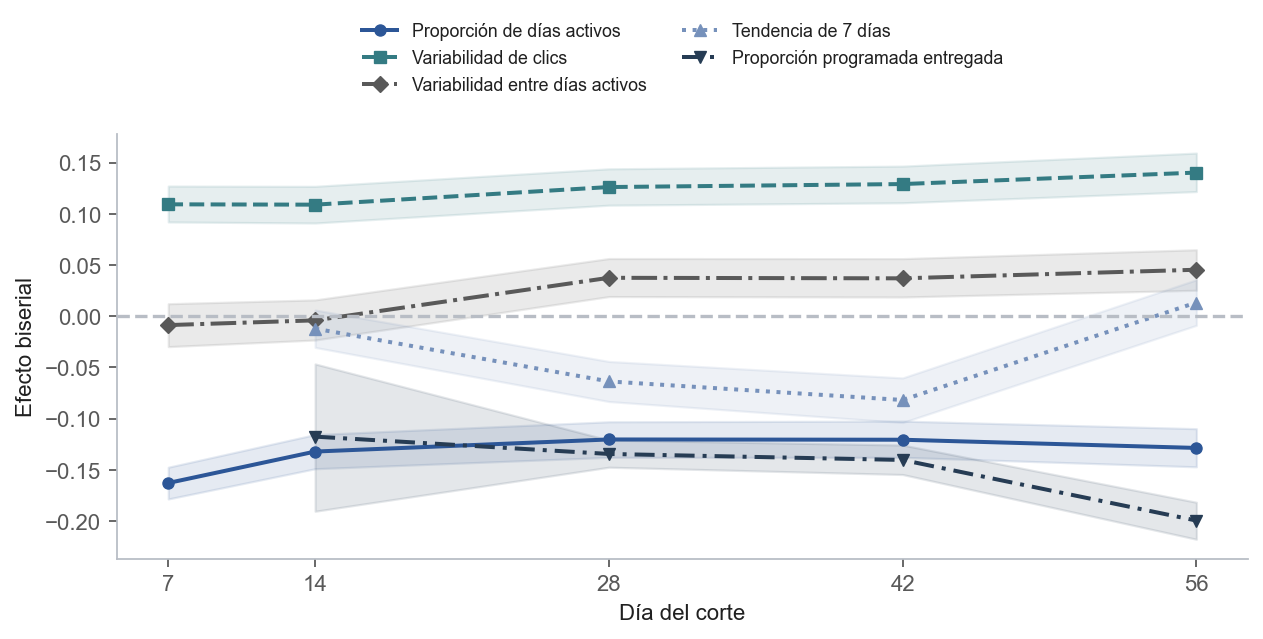

In [4]:
effects=[];bootstrap_stability=[]
for cut,d in datasets.items():
    for v in NUM:
        a=d.loc[d.retiro_futuro.eq(1),v].dropna();b=d.loc[d.retiro_futuro.eq(0),v].dropna()
        if not len(a) or not len(b):
            effects.append({'corte':cut,'variable':v,'n_retiro':len(a),'n_sin_retiro':len(b),'estado':'historia o casos insuficientes'});continue
        effect,lo,hi,n,draws=cluster_effect_ci(d,v,5000,20260908,return_draws=True)
        for B in [500,2000,5000]:
            finite=draws[:B][np.isfinite(draws[:B])];limits=np.quantile(finite,[.025,.975])
            bootstrap_stability.append({'corte':cut,'variable':v,'B':B,'validas':len(finite),'inferior':limits[0],'superior':limits[1],'cambio_max_frente_5000':max(abs(limits[0]-lo),abs(limits[1]-hi))})
        U=stats.mannwhitneyu(a,b,method='asymptotic').statistic
        assert np.isclose(effect,2*U/(len(a)*len(b))-1)
        effects.append({'corte':cut,'variable':v,'n_retiro':len(a),'n_sin_retiro':len(b),
          'efecto':effect,'IC95_inferior':lo,'IC95_superior':hi,'remuestras':n,'estado':'estimado'})
table('03_estabilidad_bootstrap',pd.DataFrame(bootstrap_stability))
effects=pd.DataFrame(effects);table('03_efectos',effects)
from figuras_oulad import efectos_cortes
efectos_cortes(effects, CUTS)
figure('03_efectos_cortes')


## 4. Heterogeneidad por módulo y categorías
V de Cramér se presenta como medida descriptiva, sin inferencia iid por filas.
Se exportan todas las tasas por categoría y corte, incluyendo niveles sin IMD.
Las diferencias entre módulos pueden reflejar calendario y composición; no se
atribuyen a una causa determinada.


In [5]:
catrows=[];levelrows=[]
for cut,d in datasets.items():
    for v in ['code_module','code_presentation','gender','age_band','highest_education','imd_band','region','disability']:
        cross=pd.crosstab(d[v].astype('string').fillna('No disponible'),d.retiro_futuro)
        chi,_,_,expected=stats.chi2_contingency(cross,correction=False)
        catrows.append({'corte':cut,'variable':v,'V_cramer':np.sqrt(chi/(cross.values.sum()*min(cross.shape[0]-1,cross.shape[1]-1))),
          'esperada_min':expected.min(),'celdas_menores5':int((expected<5).sum())})
        for level,row in cross.iterrows():
            levelrows.append({'corte':cut,'variable':v,'nivel':level,'n':int(row.sum()),
                             'retiros':int(row.get(1,0)),'tasa_pct':100*row.get(1,0)/row.sum()})
table('03_categoricas',pd.DataFrame(catrows));table('03_niveles',pd.DataFrame(levelrows))


03_categoricas
 corte          variable  V_cramer  esperada_min  celdas_menores5
     7       code_module  0.173475    165.138533                0
     7 code_presentation  0.082313    992.199752                0
     7            gender  0.034918   2956.755262                0
     7          age_band  0.026416     46.074563                0
     7 highest_education  0.071424     67.287110                0
     7          imd_band  0.072566    238.127941                0
     7            region  0.042962    253.410098                0
     7        disability  0.060885    633.639290                0
    14       code_module  0.169692    143.209524                0
    14 code_presentation  0.058749    859.058245                0
    14            gender  0.029449   2500.000713                0
    14          age_band  0.015544     39.382619                0
    14 highest_education  0.057159     54.101376                0
    14          imd_band  0.054515    206.261496             

## 5. Diagnóstico de redundancia y estructura conjunta
Se exportan Spearman y denominadores por par y corte. Las fracciones de actividad y
recencia son transformaciones de los conteos en un corte dado; no aportan variables
independientes al introducirlas conjuntamente. VIF se calcula con intercepto sobre
una especificación reducida, no como selección definitiva.

El ACP emplea los mismos cinco indicadores en todas las subpoblaciones con actividad:
log(1+clics), proporción de días activos, log(1+promedio por día activo), recencia
relativa y coeficiente de variación, estandarizados por corte. Las componentes se
ajustan por separado; sus ejes no son una trayectoria individual común. La MCD se
ajusta con hasta 5.000 inscripciones activas y usa un umbral empírico 97,5; no es una
prueba de error ni certifica cobertura chi cuadrado.


In [6]:
pca_rows=[];loads=[];vif_rows=[];mcd_rows=[]
for cut,d in datasets.items():
    cols=[v for v in NUM if d[v].notna().any()]
    d[cols].corr(method='spearman').to_csv(OUT/f'tablas/03_spearman_{cut:02d}.csv')
    (d[cols].notna().astype('int64').T@d[cols].notna().astype('int64')).to_csv(OUT/f'tablas/03_spearman_n_{cut:02d}.csv')
    assert np.allclose(d.proporcion_dias_activos*(cut+1),d.dias_activos)
    vc=['total_clics','proporcion_dias_activos','n_registros_vle','n_evaluaciones_entregadas']
    z=d[vc].to_numpy(dtype=float);z=(z-z.mean(axis=0))/z.std(axis=0)
    for j,v in enumerate(vc):
        A=np.column_stack([np.ones(len(z)),np.delete(z,j,axis=1)])
        residual=z[:,j]-A@np.linalg.lstsq(A,z[:,j],rcond=None)[0]
        ratio=np.dot(residual,residual)/np.dot(z[:,j],z[:,j])
        vif_rows.append({'corte':cut,'variable':v,'n':len(d),'VIF':1/ratio if ratio>1e-12 else np.inf})
    active=d.loc[d.dias_activos.gt(0)]
    mv=pd.DataFrame({'log_clics':np.log1p(active.total_clics),
      'proporcion_activos':active.proporcion_dias_activos,
      'log_promedio':np.log1p(active.promedio_clics_por_dia_activo),
      'recencia_relativa':active.recencia_relativa,'CV':active.coef_variacion_clics})
    Z=StandardScaler().fit_transform(mv);pca=PCA(svd_solver='full').fit(Z)
    for j,v in enumerate(pca.explained_variance_ratio_):
        pca_rows.append({'corte':cut,'n':len(active),'componente':j+1,'proporcion':v,'acumulada':pca.explained_variance_ratio_[:j+1].sum()})
    for j,name in enumerate(mv.columns):
        for k,weight in enumerate(pca.components_[:,j]):loads.append({'corte':cut,'variable':name,'componente':k+1,'carga':weight})
    rng=np.random.default_rng(20260908);idx=rng.choice(len(Z),min(5000,len(Z)),replace=False)
    mcd=MinCovDet(support_fraction=.75,random_state=20260908).fit(Z[idx]);dist=mcd.mahalanobis(Z)
    threshold=float(np.quantile(dist,.975));mcd_rows.append({'corte':cut,'n':len(Z),'muestra_ajuste':len(idx),
      'umbral_empirico':threshold,'marcadas':int((dist>threshold).sum())})
table('03_vif',pd.DataFrame(vif_rows));table('03_pca',pd.DataFrame(pca_rows))
table('03_pca_cargas',pd.DataFrame(loads));table('03_mcd',pd.DataFrame(mcd_rows))


03_vif
 corte                  variable     n       VIF
     7               total_clics 29076  3.706923
     7   proporcion_dias_activos 29076  3.387654
     7           n_registros_vle 29076  6.656388
     7 n_evaluaciones_entregadas 29076  1.051649
    14               total_clics 28054  4.451591
    14   proporcion_dias_activos 28054  4.045481
    14           n_registros_vle 28054  8.495483
    14 n_evaluaciones_entregadas 28054  1.049383
    28               total_clics 27515  5.234642
    28   proporcion_dias_activos 27515  4.696488
    28           n_registros_vle 27515 10.928959
    28 n_evaluaciones_entregadas 27515  1.319346
    42               total_clics 27005  5.839038
    42   proporcion_dias_activos 27005  5.372265
    42           n_registros_vle 27005 12.333655
    42 n_evaluaciones_entregadas 27005  1.323461
    56               total_clics 26506  6.156721
    56   proporcion_dias_activos 26506  5.673355
    56           n_registros_vle 26506 13.694293
    56 n_eval

## 6. Análisis complementario sobre inscripciones comunes
Se toma la intersección de elegibles de los cinco cortes y se fija el desenlace a
retiro después de 56 hasta el final. De este modo, la muestra y el evento son los
mismos al describir información de distintos cortes. Esta es una muestra
seleccionada retrospectivamente: excluye retiros tempranos y no representa el uso
operativo en el corte 7. Los efectos son descriptivos, no evidencia de beneficio
predictivo por esperar. No se usan para seleccionar una ventana.


In [7]:
common=pd.read_parquet(PROCESSED/'inscripciones_comunes.parquet')
target=datasets[56][KEY+['retiro_futuro']]
common_rows=[]
for cut,d in datasets.items():
    aligned=common.merge(d.drop(columns='retiro_futuro'),on=KEY,validate='one_to_one').merge(target,on=KEY,validate='one_to_one')
    for v in ['proporcion_dias_activos','coef_variacion_clics','cv_intensidad_activa','log_ratio_7d','proporcion_programadas_entregadas']:
        sub=aligned.loc[aligned[v].notna()]
        a=sub.loc[sub.retiro_futuro.eq(1),v];b=sub.loc[sub.retiro_futuro.eq(0),v]
        value=2*stats.mannwhitneyu(a,b).statistic/(len(a)*len(b))-1 if len(a) and len(b) else np.nan
        common_rows.append({'corte':cut,'variable':v,'n_cohorte':len(aligned),'n_observado':len(sub),
          'retiros_cohorte':int(aligned.retiro_futuro.sum()),'efecto':value})
table('03_cohorte_comun',pd.DataFrame(common_rows))
save_json('03_resumen.json',{'cortes':CUTS,'bootstrap_repeticiones':5000,'semilla':20260908,
 'unidad_remuestreo':'persona dentro de cada corte','intervalos':'puntuales exploratorios, no contrastes entre cortes',
 'inscripciones_comunes':len(common),'evento_comun':'56 < retiro <= final',
 'analisis_principal':'población elegible y evento propios de cada corte',
 'modelos_entrenados':False,'ventana_optima_identificada':False})
print('Comparación terminada; no se identificó ni evaluó una ventana óptima.')


03_cohorte_comun
 corte                          variable  n_cohorte  n_observado  retiros_cohorte    efecto
     7           proporcion_dias_activos      26429        26429             3985 -0.074232
     7              coef_variacion_clics      26429        22043             3985  0.066607
     7              cv_intensidad_activa      26429        17514             3985 -0.011113
     7                      log_ratio_7d      26429            0             3985       NaN
     7 proporcion_programadas_entregadas      26429            0             3985       NaN
    14           proporcion_dias_activos      26429        26429             3985 -0.087390
    14              coef_variacion_clics      26429        24184             3985  0.082200
    14              cv_intensidad_activa      26429        21678             3985  0.000128
    14                      log_ratio_7d      26429        24032             3985 -0.010165
    14 proporcion_programadas_entregadas      26429         124

## 7. Referencias y continuidad
Se mantienen las fuentes consultadas: Kuzilek, Hlosta y Zdrahal (2017), Scientific
Data 4:170171, DOI 10.1038/sdata.2017.171; Field y Welsh (2007), JRSS B 69(3),
369-390, DOI 10.1111/j.1467-9868.2007.00593.x; documentación oficial de SciPy
(`mannwhitneyu`) y scikit-learn (`PCA`, `MinCovDet`, validación y prevención de fugas).
Las fuentes y límites de consulta se conservan en el registro bibliográfico.
La fase siguiente deberá comparar modelos con particiones coherentes entre ventanas,
preprocesamiento dentro de entrenamiento y un criterio que considere anticipación.


## 8. Sensibilidades y evidencia documental
Se contrastan agregaciones completas, CV activo, PCA y duplicados. Los productos amplían el análisis y no constituyen entrenamiento predictivo.

02_particion_exclusiones
 corte  matricula_desconocida  matricula_posterior  retiro_preinicio_tras_matricula  retiro_0_t_tras_matricula  fin_no_posterior  elegibles
     7                     45                   93                             2643                        736                 0      29076
    14                     45                   58                             2643                       1793                 0      28054
    28                     45                   16                             2643                       2374                 0      27515
    42                     45                   12                             2643                       2888                 0      27005
    56                     45                    9                             2643                       3390                 0      26506
03_comparacion_cv
 corte     n  observados_calendario  observados_activos  rho_calendario_q  rho_calendario_q_mismos  rho_activo_q
    

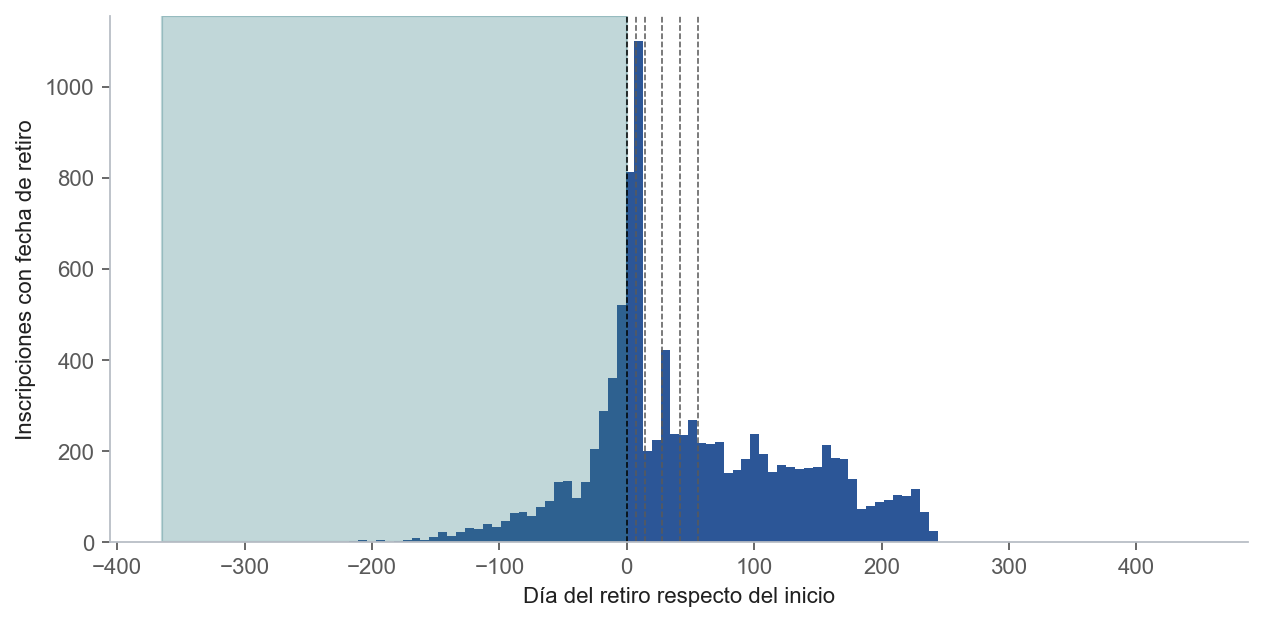

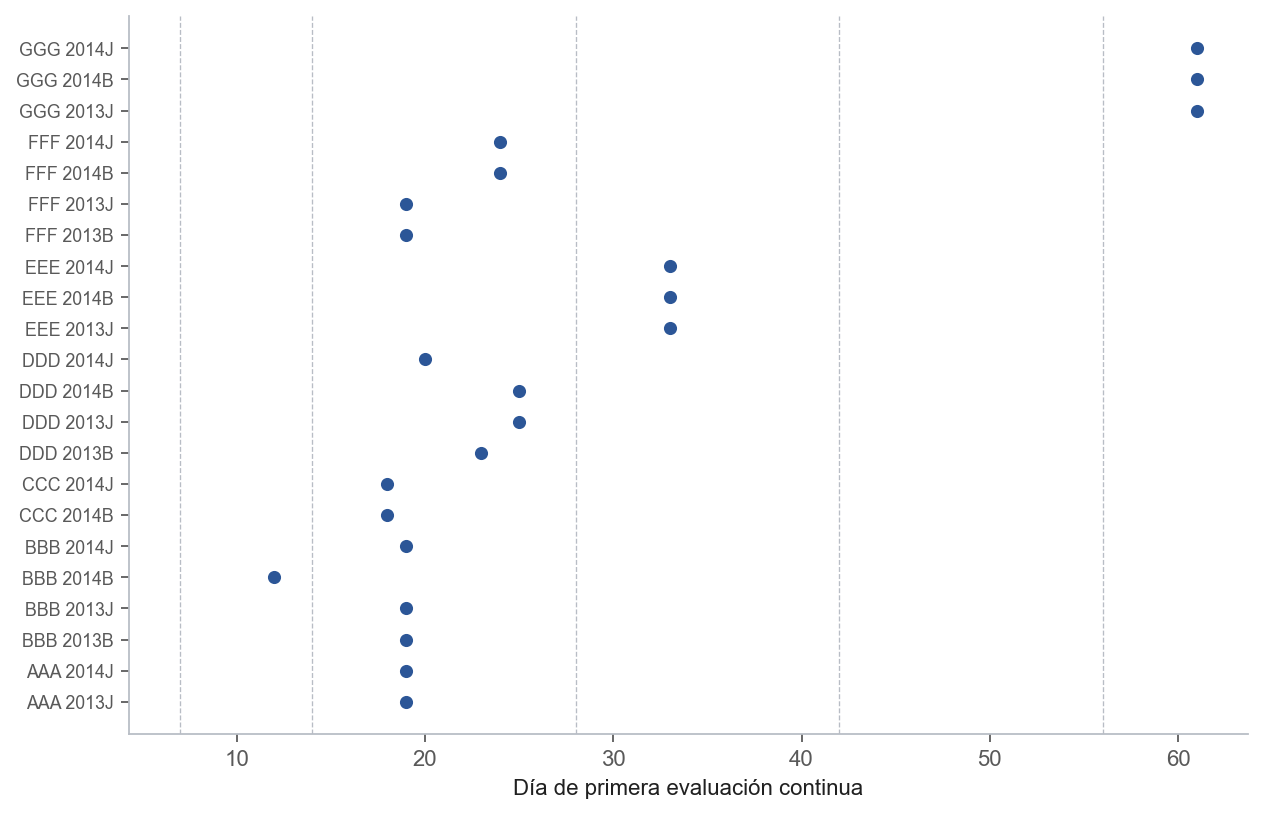

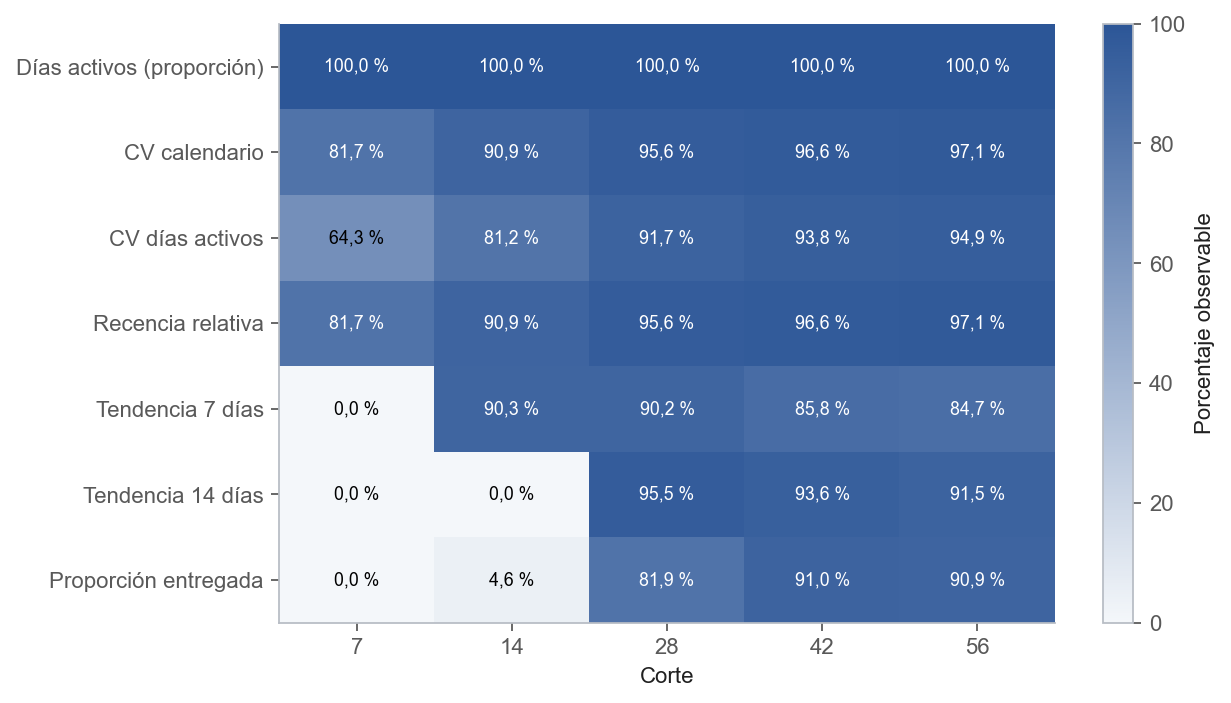

In [8]:
from ampliacion_oulad import ejecutar_ampliacion
ejecutar_ampliacion(datasets)
